In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
orders = pd.read_csv("data/raw/olist_orders_dataset.csv")

customers = pd.read_csv("data/raw/olist_customers_dataset.csv")

payments = pd.read_csv("data/raw/olist_order_payments_dataset.csv")

items = pd.read_csv("data/raw/olist_order_items_dataset.csv")

products = pd.read_csv("data/raw/olist_products_dataset.csv")

In [4]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [5]:
orders.shape


(99441, 8)

In [6]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 21.9 MB


In [7]:
orders['order_purchase_timestamp'] = pd.to_datetime(
    orders['order_purchase_timestamp']
)

In [8]:
orders['Month'] = orders['order_purchase_timestamp'].dt.month

orders['Year'] = orders['order_purchase_timestamp'].dt.year

In [9]:
df = pd.merge(
    orders,
    customers,
    on='customer_id',
    how='inner'
)

In [10]:
df = pd.merge(
    df,
    items,
    on='order_id',
    how='inner'
)

In [11]:
df = pd.merge(
    df,
    payments,
    on='order_id',
    how='inner'
)

In [12]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,Month,Year,...,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,10,2017,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,10,2017,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,10,2017,...,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,7,2018,...,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,8,2018,...,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,1,credit_card,3,179.12


In [13]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 117601 entries, 0 to 117600
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       117601 non-null  str           
 1   customer_id                    117601 non-null  str           
 2   order_status                   117601 non-null  str           
 3   order_purchase_timestamp       117601 non-null  datetime64[us]
 4   order_approved_at              117586 non-null  str           
 5   order_delivered_carrier_date   116356 non-null  str           
 6   order_delivered_customer_date  115034 non-null  str           
 7   order_estimated_delivery_date  117601 non-null  str           
 8   Month                          117601 non-null  int32         
 9   Year                           117601 non-null  int32         
 10  customer_unique_id             117601 non-null  str           
 11  customer_zi

In [14]:
total_revenue = df['payment_value'].sum()

print(total_revenue)

20308134.71


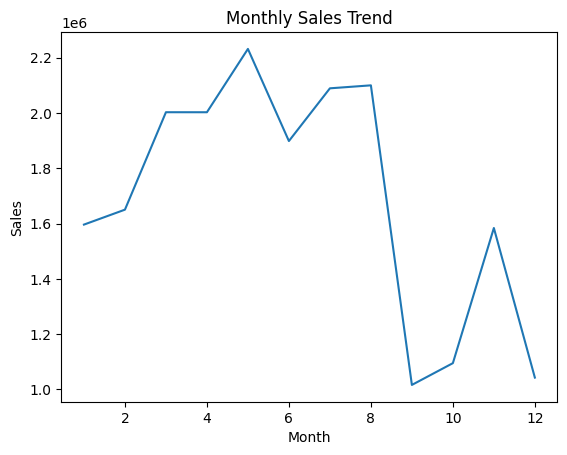

In [15]:
monthly_sales = df.groupby('Month')['payment_value'].sum()

monthly_sales.plot(kind='line')

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.show()

In [16]:
df.isnull().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                  15
order_delivered_carrier_date     1245
order_delivered_customer_date    2567
order_estimated_delivery_date       0
Month                               0
Year                                0
customer_unique_id                  0
customer_zip_code_prefix            0
customer_city                       0
customer_state                      0
order_item_id                       0
product_id                          0
seller_id                           0
shipping_limit_date                 0
price                               0
freight_value                       0
payment_sequential                  0
payment_type                        0
payment_installments                0
payment_value                       0
dtype: int64

In [17]:
df.duplicated().sum()

np.int64(0)

In [18]:
df.drop_duplicates(inplace=True)

In [19]:
df.describe()

,order_purchase_timestamp,Month,Year,customer_zip_code_prefix,order_item_id,price,freight_value,payment_sequential,payment_installments,payment_value
count,117601,117601.000000,117601.000000,117601.000000,117601.000000,117601.000000,117601.000000,117601.000000,117601.000000,117601.000000
mean,2017-12-30 16:19:35.878368,6.028129,2017.538193,35051.793097,1.195900,120.824783,20.045990,1.093528,2.939482,172.686752
min,2016-09-04 21:15:19,1.000000,2016.000000,1003.000000,1.000000,0.850000,0.000000,1.000000,0.000000,0.000000
25%,2017-09-11 21:42:39,3.000000,2017.000000,11310.000000,1.000000,39.900000,13.080000,1.000000,1.000000,60.870000
50%,2018-01-18 13:37:27,6.000000,2018.000000,24315.000000,1.000000,74.900000,16.290000,1.000000,2.000000,108.210000
75%,2018-05-03 22:43:17,8.000000,2018.000000,58600.000000,1.000000,134.900000,21.190000,1.000000,4.000000,189.260000
max,2018-09-03 09:06:57,12.000000,2018.000000,99990.000000,21.000000,6735.000000,409.680000,29.000000,24.000000,13664.080000
std,NaN,3.229579,0.505065,29820.588877,0.697706,184.479323,15.861315,0.726692,2.774223,267.592290


In [20]:
total_orders = df['order_id'].nunique()

print("Total Orders:", total_orders)

Total Orders: 98665


In [21]:
total_customers = df['customer_unique_id'].nunique()

print("Total Customers:", total_customers)

Total Customers: 95419


In [22]:
aov = df['payment_value'].sum() / total_orders

print("Average Order Value:", aov)

Average Order Value: 205.82916647240663


In [23]:
payment_methods = df['payment_type'].value_counts()

print(payment_methods)

payment_type
credit_card    86769
boleto         22867
voucher         6274
debit_card      1691
Name: count, dtype: int64


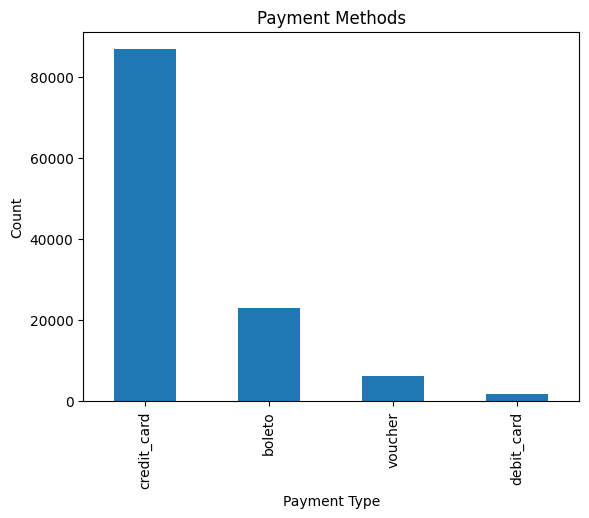

In [24]:
payment_methods.plot(kind='bar')

plt.title("Payment Methods")

plt.xlabel("Payment Type")

plt.ylabel("Count")

plt.show()

In [25]:
monthly_sales = df.groupby('Month')['payment_value'].sum()

print(monthly_sales)

Month
1     1596145.06
2     1650183.59
3     2002561.61
4     2002477.05
5     2231479.39
6     1898348.08
7     2088998.42
8     2099749.62
9     1016363.55
10    1095083.85
11    1583869.01
12    1042875.48
Name: payment_value, dtype: float64


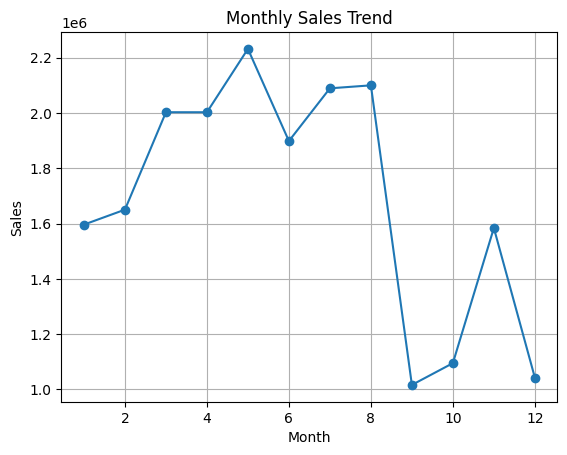

In [26]:
monthly_sales.plot(kind='line', marker='o')

plt.title("Monthly Sales Trend")

plt.xlabel("Month")

plt.ylabel("Sales")

plt.grid()

plt.show()

In [27]:
top_customers = df.groupby('customer_unique_id')['payment_value'].sum() \
                  .sort_values(ascending=False) \
                  .head(10)

print(top_customers)

customer_unique_id
0a0a92112bd4c708ca5fde585afaa872    109312.64
698e1cf81d01a3d389d96145f7fa6df8     45256.00
c402f431464c72e27330a67f7b94d4fb     44048.00
4007669dec559734d6f53e029e360987     36489.24
ef8d54b3797ea4db1d63f0ced6a906e9     30186.00
763c8b1c9c68a0229c42c9fc6f662b93     29099.52
c8460e4251689ba205045f3ea17884a1     27935.46
eae0a83d752b1dd32697e0e7b4221656     25051.89
3d47f4368ccc8e1bb4c4a12dbda7111b     22346.60
adfa1cab2b2c8706db21bb13c0a1beb1     19457.04
Name: payment_value, dtype: float64


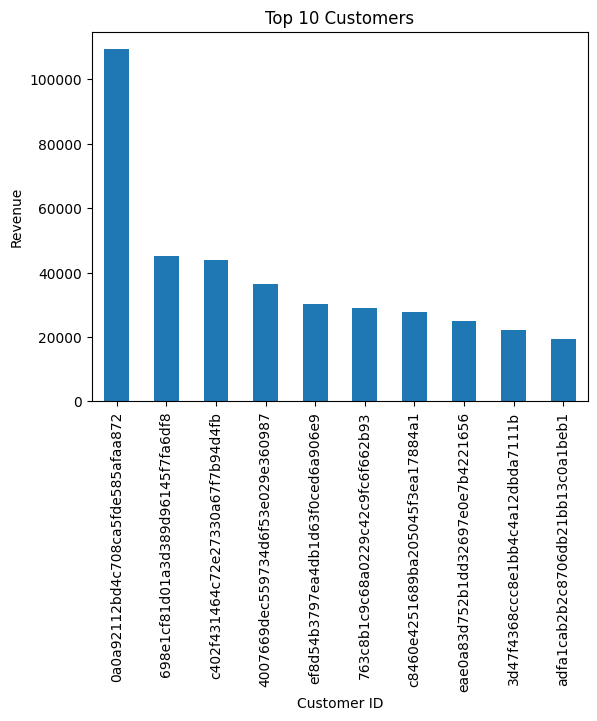

In [28]:
top_customers.plot(kind='bar')

plt.title("Top 10 Customers")

plt.xlabel("Customer ID")

plt.ylabel("Revenue")

plt.show()

In [29]:
top_products = df.groupby('product_id')['payment_value'].sum() \
                 .sort_values(ascending=False) \
                 .head(10)

print(top_products)

product_id
5769ef0a239114ac3a854af00df129e4    109312.64
bb50f2e236e5eea0100680137654686c     81887.42
422879e10f46682990de24d770e7f83d     79512.22
d1c427060a0f73f6b889a5c7c61f2ac4     70557.90
6cdd53843498f92890544667809f1595     64825.67
d5991653e037ccb7af6ed7d94246b249     64143.26
aca2eb7d00ea1a7b8ebd4e68314663af     63788.12
a62e25e09e05e6faf31d90c6ec1aa3d1     63167.37
99a4788cb24856965c36a24e339b6058     63161.40
3dd2a17168ec895c781a9191c1e95ad7     58962.14
Name: payment_value, dtype: float64


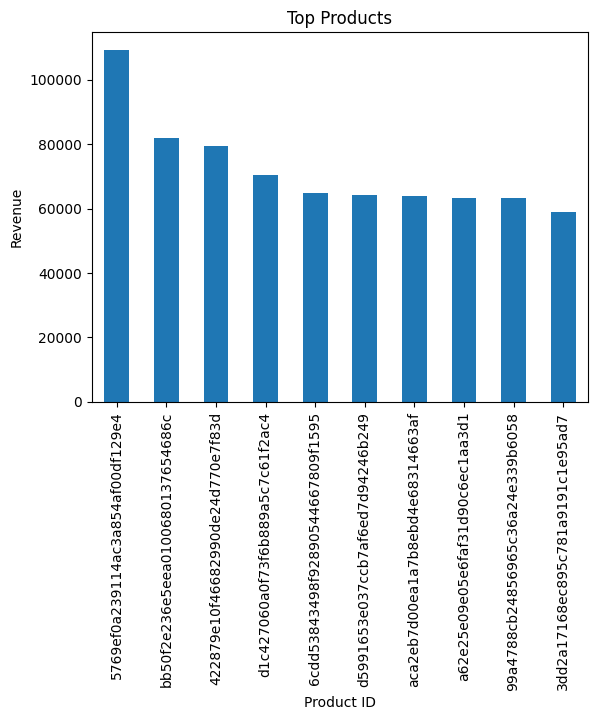

In [30]:
top_products.plot(kind='bar')

plt.title("Top Products")

plt.xlabel("Product ID")

plt.ylabel("Revenue")

plt.show()

In [31]:
df.to_csv(
    "data/cleaned/cleaned_ecommerce_data.csv",
    index=False
)